## PtyChee iCoM Demo

Running 'find best rotate angle' and calculating iCoM

Author: Zeyu Wang <br>
October 2025

In [1]:
import numpy as np
from PtyChee import run

4D-STEM data and parameters read in, this data uesd a total dose of only ~36 e<sup>-</sup>/Å<sup>2</sup>.

In [2]:
file_read = 'data/'
file = 'MAPbI3_HT200_a13_ss0.3_31_F3sum.npy'
data_4D = np.load(file_read+file)
print(data_4D.shape)

Voltage = 200               #keV, accelerate votage
alpha = 0.013               #rad, semi convergence angle
scan_step = 0.3             #Å,   scan step size

(800, 800, 38, 38)


Run PtyChee.finRotate to calculate the optimized scan rotate angle


find best rotate angle and flip
File: MAPbI3_HT200_a13_ss0.3_31_F3sum.npy

#################### Data Information ####################
data shape: (800, 800, 38, 38)
data type: int8
CBED intensity range: 0 – 14
average CBED intensity: 9.6288480758667
BF center_Y: 18.581818181818182
BF center_X: 18.663636363636364
BF threshold: 0.5
Aperture Radius: 5.843108646253187 pixels

################## Original CoM Process ##################
inner_radiuss: 0 Alpha
outer_radius: 3 Alpha

################# Calculating Curl Curve #################
Best Scan Rotate Angle: 4.0 or -176.0 degrees
No Need to Flip

################### Saving and Ploting ###################
curl curve saving


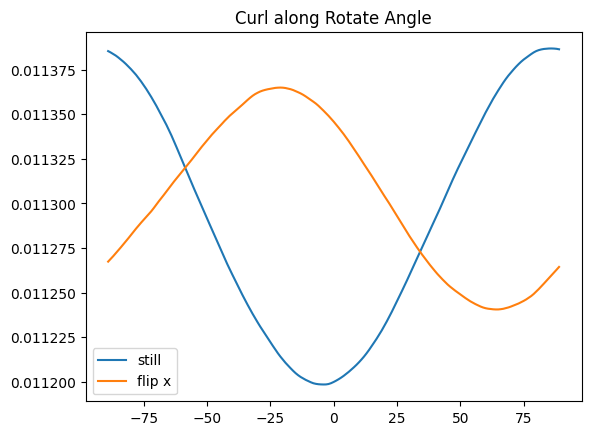

In [3]:
# Find Best Rotate and Flip From Curl
run.run_findRotateFromCurl(file, data_4D,
        inner_radius = 0,              # inner radius for the annular ROI on CBED
        outer_radius = 3,              # outer radius for the annular ROI on CBED
        save_results = False,
)

according to the calculation result, we set scan_rotation_angle as '-176', note that set it to '4' in this case will cause an inversed contrast, <br>
and set scan_flip as 'False'

In [4]:
scan_rotation_angle = -176   #degrees
scan_flip = False            #flip X axis or not

Run CoM and iCoM


iCoM
File: MAPbI3_HT200_a13_ss0.3_31_F3sum.npy

################ Experimental Information ################
scan rotation angle: -176 degrees
scan flip x: False

#################### Data Information ####################
data shape: (800, 800, 38, 38)
data type: int8
CBED intensity range: 0 – 14
average CBED intensity: 9.6288480758667
BF center_Y: 18.581818181818182
BF center_X: 18.663636363636364
BF threshold: 0.5
Aperture Radius: 5.843108646253187 pixels

################## Original CoM Process ##################
inner_radiuss: 0 Alpha
outer_radius: 3 Alpha

##################### CoM Parameters #####################
CoM rotation angle: 176 degrees
CoM flip x: False

################# Jacobi iCoM Parameters #################
Number of Iterations: 100

################### Saving and Ploting ###################
CoM saving


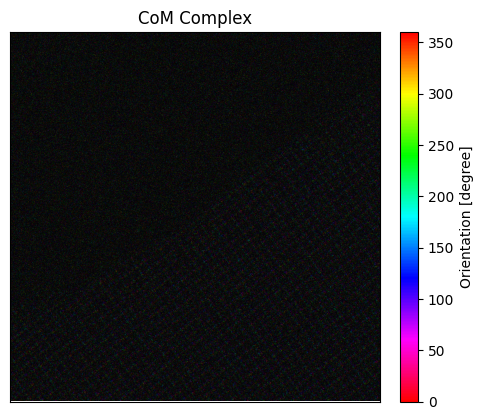

iCoM saving


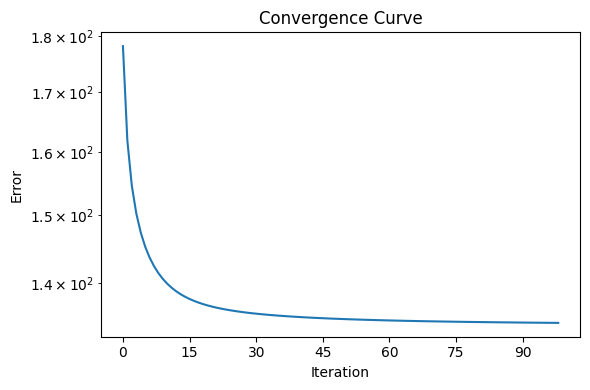

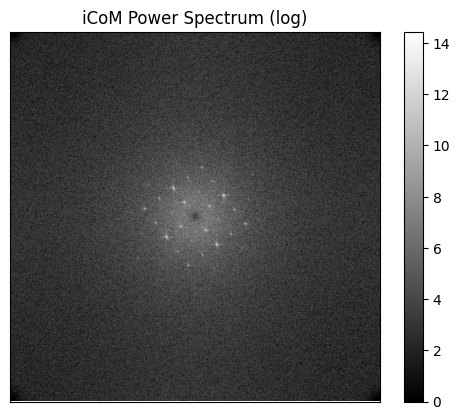

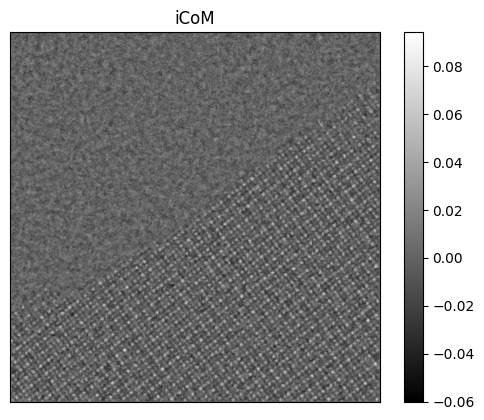

In [ ]:
# CoM & iCoM
run.run_iCoM(file, data_4D, scan_rotation_angle, scan_flip, 
        inner_radius = 0,              # inner radius for the annular ROI on CBED
        outer_radius = 3,              # outer radius for the annular ROI on CBED

        mode = 'jacobi',               # 'anal' or 'iter' or 'jacobi'
        n_iter = 100,                  # iteration nunber for jacobi iCoM

        save_results = False,
)